In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('c:\\Users\\ABC\\AppData\\Local\\Temp\\Rar$DRa16008.8382\\placement.csv')
df.sample(5)

,Unnamed: 0,cgpa,iq,placement
15,15,5.1,176.0,0
68,68,4.0,75.0,0
93,93,6.8,112.0,1
30,30,7.6,128.0,1
2,2,5.3,121.0,0


In [13]:
df.shape

(100, 5)

C:\Users\ABC\AppData\Local\Temp\ipykernel_2356\2737363918.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\ABC\AppData\Local\Temp\ipykernel_2356\2737363918.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['iq'])


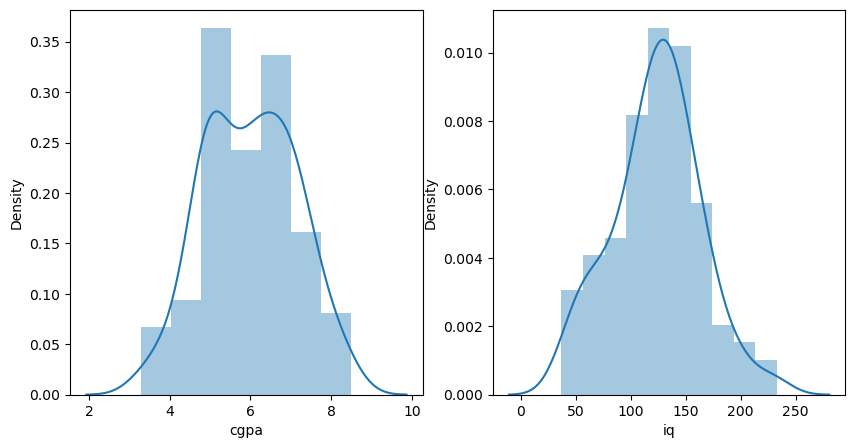

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.distplot(df['cgpa'])
plt.subplot(1, 2, 2)
sns.distplot(df['iq'])
plt.show()

In [15]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std vale of cpga",df['cgpa'].std())
print("Min value of cgpa ",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 5.9910000000000005
Std vale of cpga 1.1436336737775692
Min value of cgpa  3.3
Max value of cgpa 8.5


In [16]:
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 9.421901021332708
Lowest allowed 2.560098978667293


In [17]:
df[(df['cgpa']> 8.5) | (df['cgpa'] < 5.11)]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
7,7,5.0,63.0,0,-0.866536
9,9,5.1,66.0,0,-0.779096
15,15,5.1,176.0,0,-0.779096
17,17,3.3,183.0,0,-2.353026
18,18,4.0,100.0,0,-1.740942
22,22,4.9,120.0,0,-0.953977
23,23,4.7,87.0,0,-1.128858
24,24,4.7,121.0,0,-1.128858
25,25,5.0,91.0,0,-0.866536
31,31,3.9,109.0,0,-1.828383


In [18]:
# triming
new_df = df[(df['cgpa'] < 8.5) & (df['cgpa'] > 5.11)]
new_df
            

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012
...,...,...,...,...,...
92,92,5.2,110.0,0,-0.691655
93,93,6.8,112.0,1,0.707394
97,97,6.7,182.0,1,0.619954
98,98,6.3,103.0,1,0.270191


In [19]:
df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
df.head()

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012


In [21]:
df[df['cgpa_zscore'] > 3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore


In [22]:
df[df['cgpa_zscore'] > -3]

,Unnamed: 0,cgpa,iq,placement,cgpa_zscore
0,0,6.8,123.0,1,0.707394
1,1,5.9,106.0,0,-0.079571
2,2,5.3,121.0,0,-0.604214
3,3,7.4,132.0,1,1.232038
4,4,5.8,142.0,0,-0.167012
...,...,...,...,...,...
95,95,4.3,200.0,0,-1.478620
96,96,4.4,42.0,0,-1.391180
97,97,6.7,182.0,1,0.619954
98,98,6.3,103.0,1,0.270191


capping

In [24]:
upper_limit = df['cgpa'].mean() +3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() -3*df['cgpa'].std()
upper_limit
lower_limit

np.float64(2.560098978667293)

In [25]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [26]:
df.shape

(100, 5)

In [27]:
df['cgpa'].describe()

count    100.000000
mean       5.991000
std        1.143634
min        3.300000
25%        5.075000
50%        6.000000
75%        6.900000
max        8.500000
Name: cgpa, dtype: float64